In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import re

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID","Brand","Sentiment","Tweet"]
)

df.head()

,ID,Brand,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [11]:
df.shape

df.info()

df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Brand      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


,ID,Brand,Sentiment,Tweet
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,TomClancysRainbowSix,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


In [12]:
df.isnull().sum()

ID             0
Brand          0
Sentiment      0
Tweet        686
dtype: int64

In [13]:
df.dropna(inplace=True)

df.reset_index(drop=True,inplace=True)

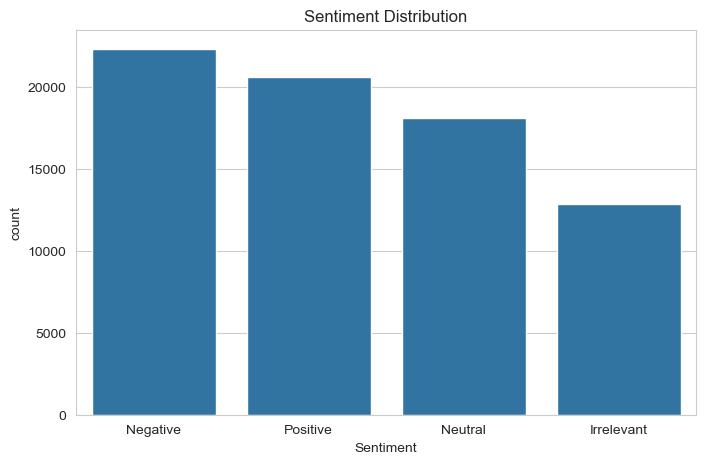

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")

plt.savefig("sentiment_distribution.png",dpi=300)

plt.show()

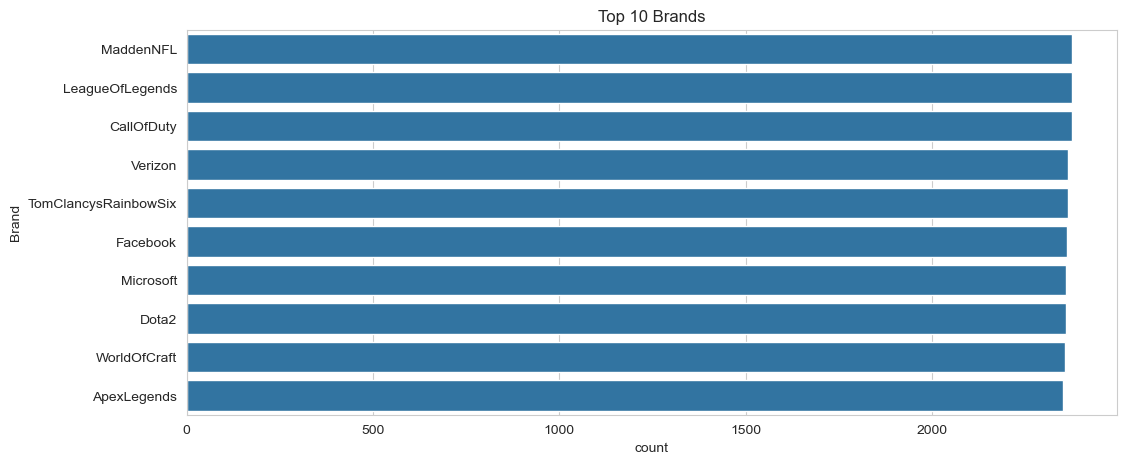

In [15]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y="Brand",
    order=df["Brand"].value_counts().head(10).index
)

plt.title("Top 10 Brands")

plt.savefig("brand_distribution.png",dpi=300)

plt.show()

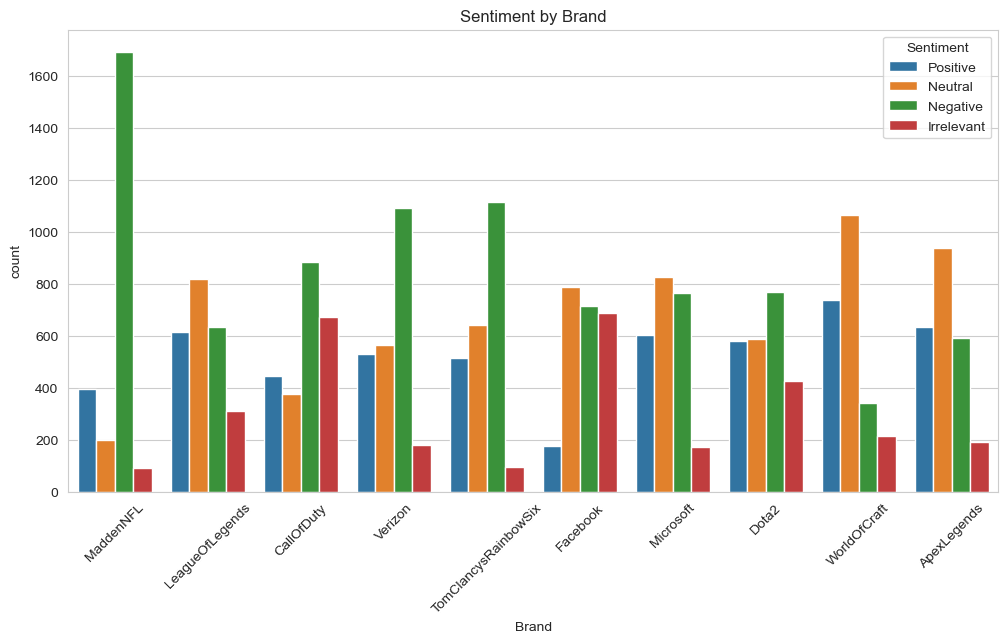

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Brand",
    hue="Sentiment",
    order=df["Brand"].value_counts().head(10).index
)

plt.xticks(rotation=45)

plt.title("Sentiment by Brand")

plt.savefig("sentiment_by_brand.png",dpi=300)

plt.show()

In [17]:
def clean_text(text):

    text=str(text)

    text=re.sub(r"http\S+","",text)

    text=re.sub(r"@\w+","",text)

    text=re.sub(r"#","",text)

    text=re.sub(r"[^A-Za-z ]","",text)

    return text.lower()

df["Clean_Tweet"]=df["Tweet"].apply(clean_text)

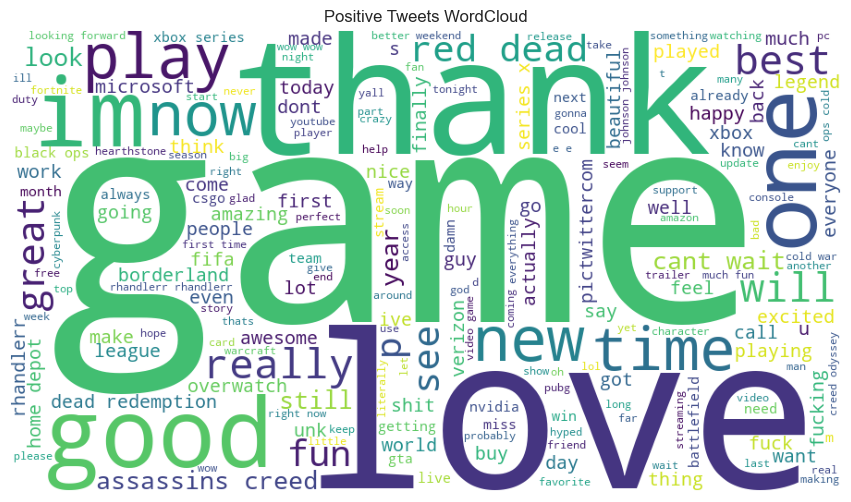

In [18]:
positive=" ".join(
    df[df["Sentiment"]=="Positive"]["Clean_Tweet"]
)

wc=WordCloud(
    background_color="white",
    width=900,
    height=500
).generate(positive)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Positive Tweets WordCloud")

plt.savefig("wordcloud_positive.png",dpi=300)

plt.show()

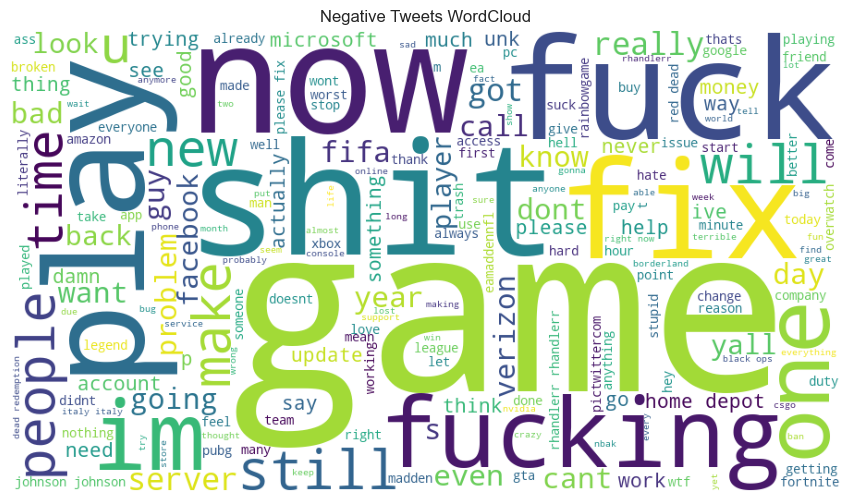

In [19]:
negative=" ".join(
    df[df["Sentiment"]=="Negative"]["Clean_Tweet"]
)

wc=WordCloud(
    background_color="white",
    width=900,
    height=500
).generate(negative)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Negative Tweets WordCloud")

plt.savefig("wordcloud_negative.png",dpi=300)

plt.show()

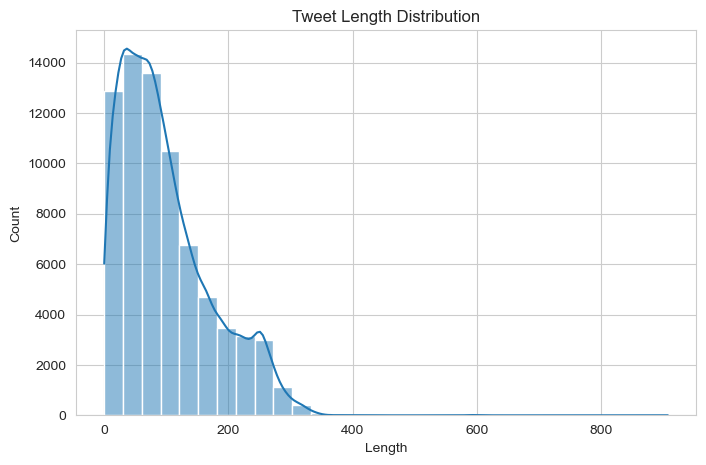

In [20]:
df["Length"]=df["Clean_Tweet"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["Length"],bins=30,kde=True)

plt.title("Tweet Length Distribution")

plt.savefig("tweet_length_distribution.png",dpi=300)

plt.show()

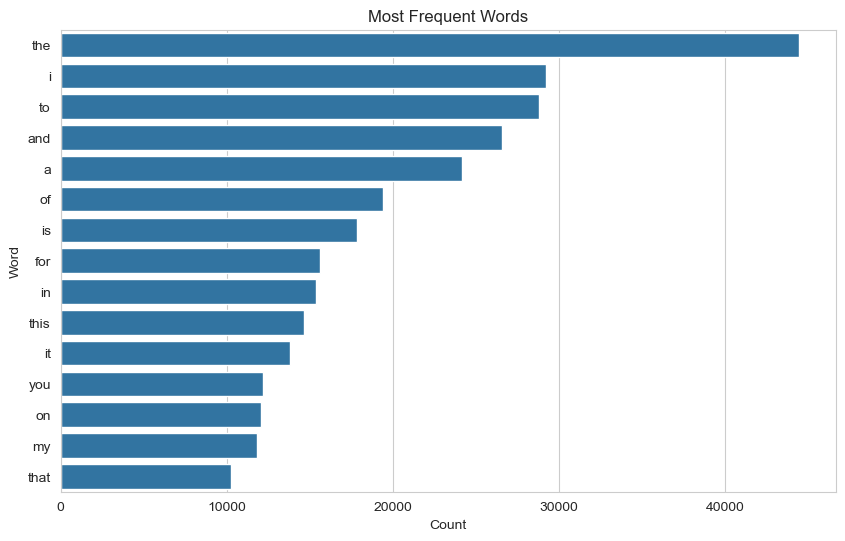

In [21]:
from collections import Counter

words=" ".join(df["Clean_Tweet"]).split()

top=Counter(words).most_common(15)

top_df=pd.DataFrame(top,columns=["Word","Count"])

plt.figure(figsize=(10,6))

sns.barplot(data=top_df,x="Count",y="Word")

plt.title("Most Frequent Words")

plt.savefig("top_words.png",dpi=300)

plt.show()

In [22]:
df.to_csv("cleaned_dataset.csv",index=False)

In [23]:
print(df["Sentiment"].value_counts())

print(df.groupby("Brand")["Sentiment"].value_counts().head(20))

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64
Brand           Sentiment 
Amazon          Neutral       1207
                Negative       575
                Positive       308
                Irrelevant     186
ApexLegends     Neutral        936
                Positive       634
                Negative       591
                Irrelevant     192
AssassinsCreed  Positive      1439
                Negative       375
                Irrelevant     264
                Neutral        156
Battlefield     Irrelevant     915
                Positive       586
                Negative       464
                Neutral        351
Borderlands     Positive      1017
                Neutral        597
                Negative       426
                Irrelevant     240
Name: count, dtype: int64
